# Analysis and Visualization of ZTF alerts

Part 2 continuation of intro_to_frigate notebook.

In [83]:
# prep data for plotting

from frigate_plots import PrepPlotter
testnight, name = PrepPlotter('./private_data/2460097.5_2460098.5_1_2_3.parquet', cut_drb=0.4, ignore_scores=True).prep_data()

Loaded 1 nights of alerts


# Feature importance

### With Pearson correlation matrix

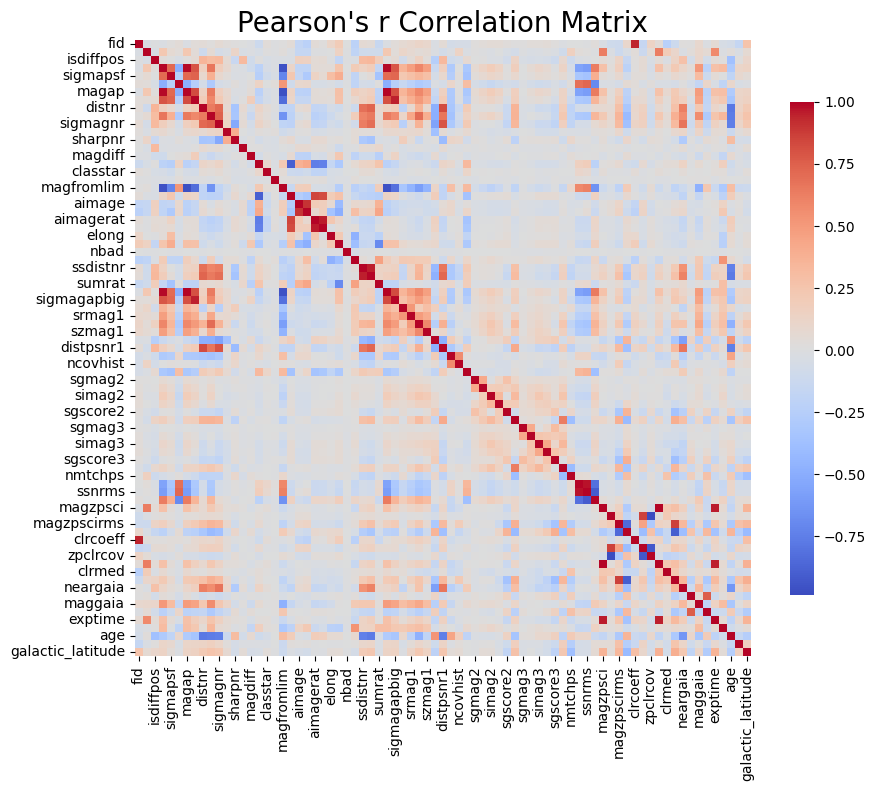

magzpsci + zpmed (Correlation: 1.0)
magap + magapbig (Correlation: 0.99)
magpsf + magap (Correlation: 0.99)


In [19]:
from frigate_plots import PearsonCorrelation
pearsoncorr = PearsonCorrelation(testnight)
pearsoncorr.plot_correlation_matrix(threshold=0.5)
pearsoncorr.print_highest_correlations(threshold=0.99)

### with RF (MDI and feature permutation)

In [71]:
from frigate_plots import RandomForest
rf = RandomForest(testnight, target_column='filtered_bool', use_weight=True, save=False)
rf.train_rf()

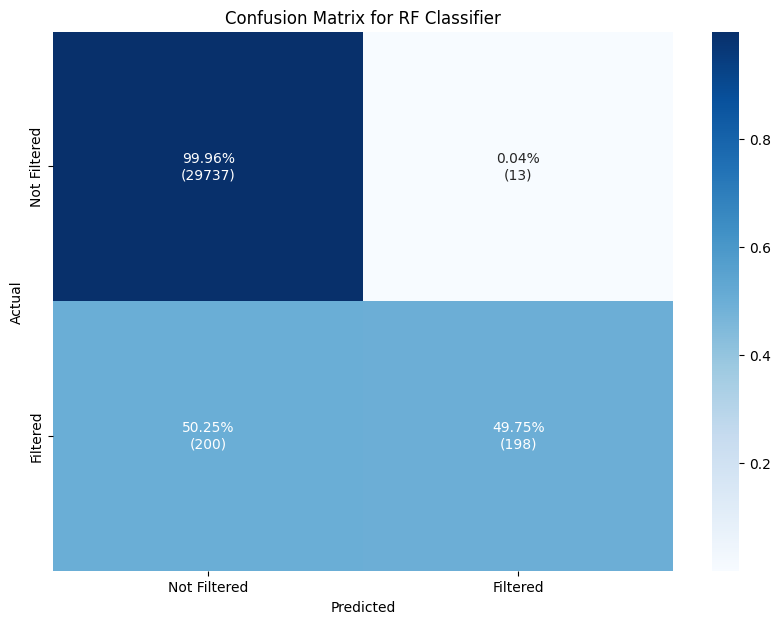

Accuracy: 0.99
Precision: 0.99
Recall: 0.99
F1 Score: 0.99

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     29750
           1       0.94      0.50      0.65       398

    accuracy                           0.99     30148
   macro avg       0.97      0.75      0.82     30148
weighted avg       0.99      0.99      0.99     30148



In [63]:
rf.rf_confusion_matric()

Elapsed time to compute the importances: 0.026 seconds
galactic_latitude    0.117909
clrrms               0.060876
diffmaglim           0.037993
sharpnr              0.037023
age                  0.036566
nmatches             0.034666
nmtchps              0.033822
magzpscirms          0.031016
chinr                0.030885
sgscore1             0.027890
ndethist             0.023443
magnr                0.022014
srmag1               0.021777
ncovhist             0.020923
clrcoeff             0.019211
sigmagnr             0.018835
simag1               0.018106
magzpsciunc          0.017873
zpclrcov             0.016360
clrcounc             0.015309
dtype: float64


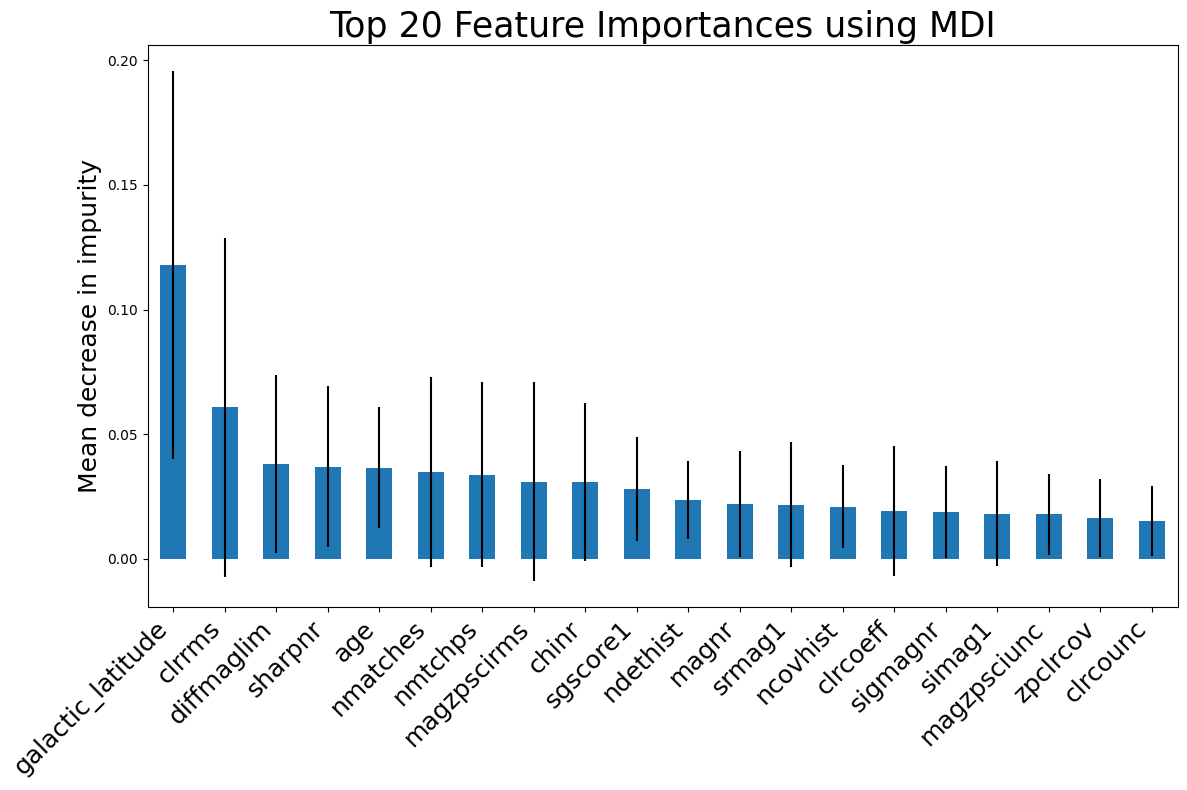

In [68]:
rf.get_mdi()

Elapsed time to compute the importances: 115.060 seconds
galactic_latitude    0.004216
clrrms               0.003217
ncovhist             0.001887
nmatches             0.001380
diffmaglim           0.001360
magzpscirms          0.001264
age                  0.001237
clrmed               0.000909
magnr                0.000730
sharpnr              0.000723
clrcoeff             0.000720
ndethist             0.000693
nmtchps              0.000683
magzpsciunc          0.000634
chinr                0.000624
zpclrcov             0.000600
sgscore1             0.000587
sigmagnr             0.000524
isdiffpos            0.000491
clrcounc             0.000481
dtype: float64


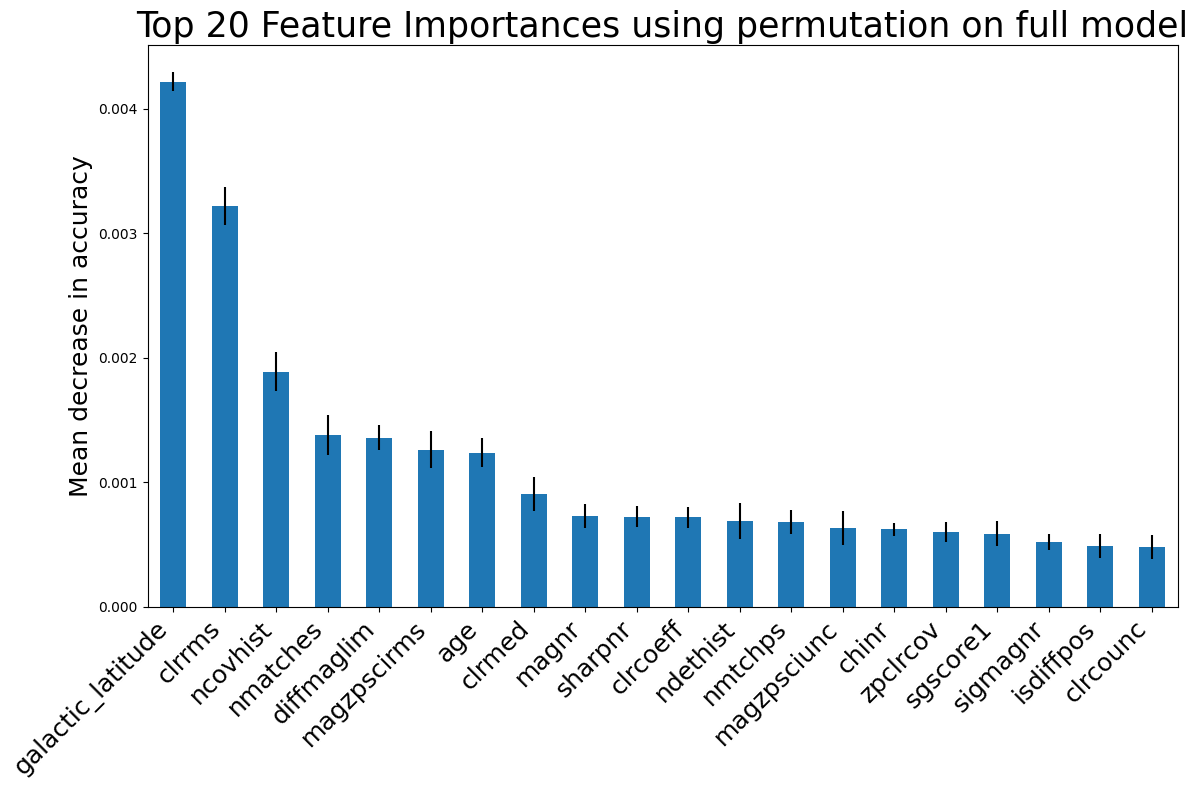

In [72]:
rf.get_feature_permutation()

### Principle Component Analysis

In [109]:
from frigate_plots import PrincipleComponentAnalysis
pca = PrincipleComponentAnalysis(testnight)
pca.get_PCA()

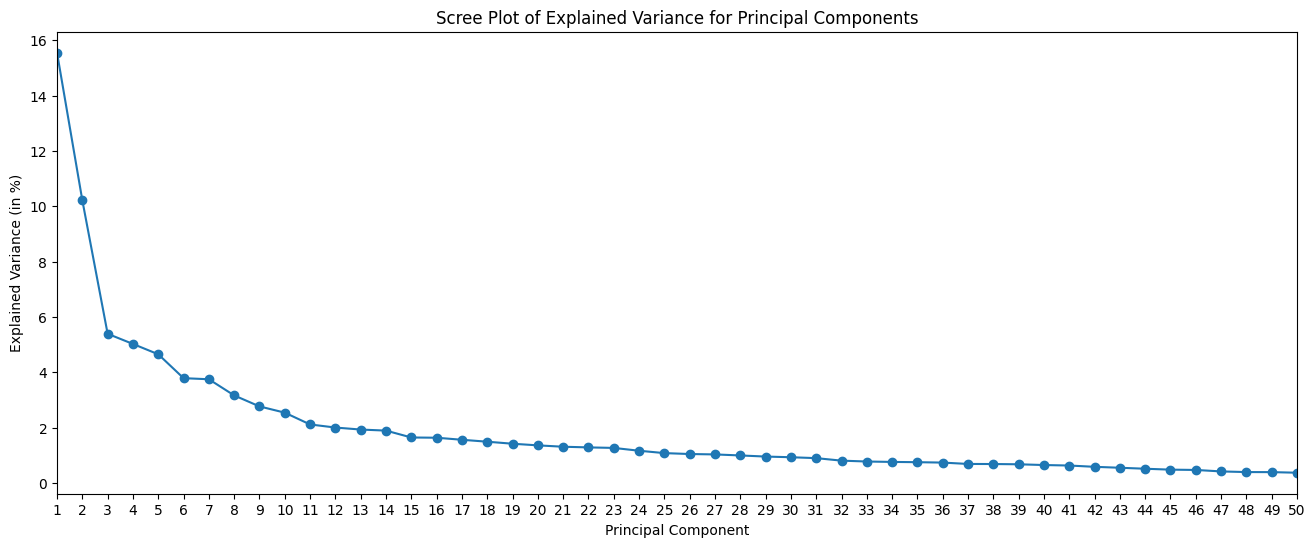

In [110]:
pca.scree_plot()

In [111]:
pca.rank_pca_components()

Component 1:
       feature        PC
26        nbad  0.000505
16    classtar  0.000849
17  mindtoedge  0.006260
50      simag3  0.006857
48      sgmag3  0.007386
51      szmag3  0.007567
49      srmag3  0.007829
24       elong  0.008091
13         sky  0.011259
0          fid  0.013207
19    seeratio  0.014989
15        fwhm  0.017173
14     magdiff  0.017253
42      sgmag2  0.017403
30      sumrat  0.018260
Component 2:
       feature        PC
73         drb  0.000049
39    ndethist  0.000217
26        nbad  0.000899
62    clrcoeff  0.004062
17  mindtoedge  0.004751
27          rb  0.009960
70     maggaia  0.016461
35      simag1  0.019926
11       chinr  0.023657
40    ncovhist  0.025516
66      clrmed  0.026955
0          fid  0.028975
48      sgmag3  0.029949
13         sky  0.030171
42      sgmag2  0.030191


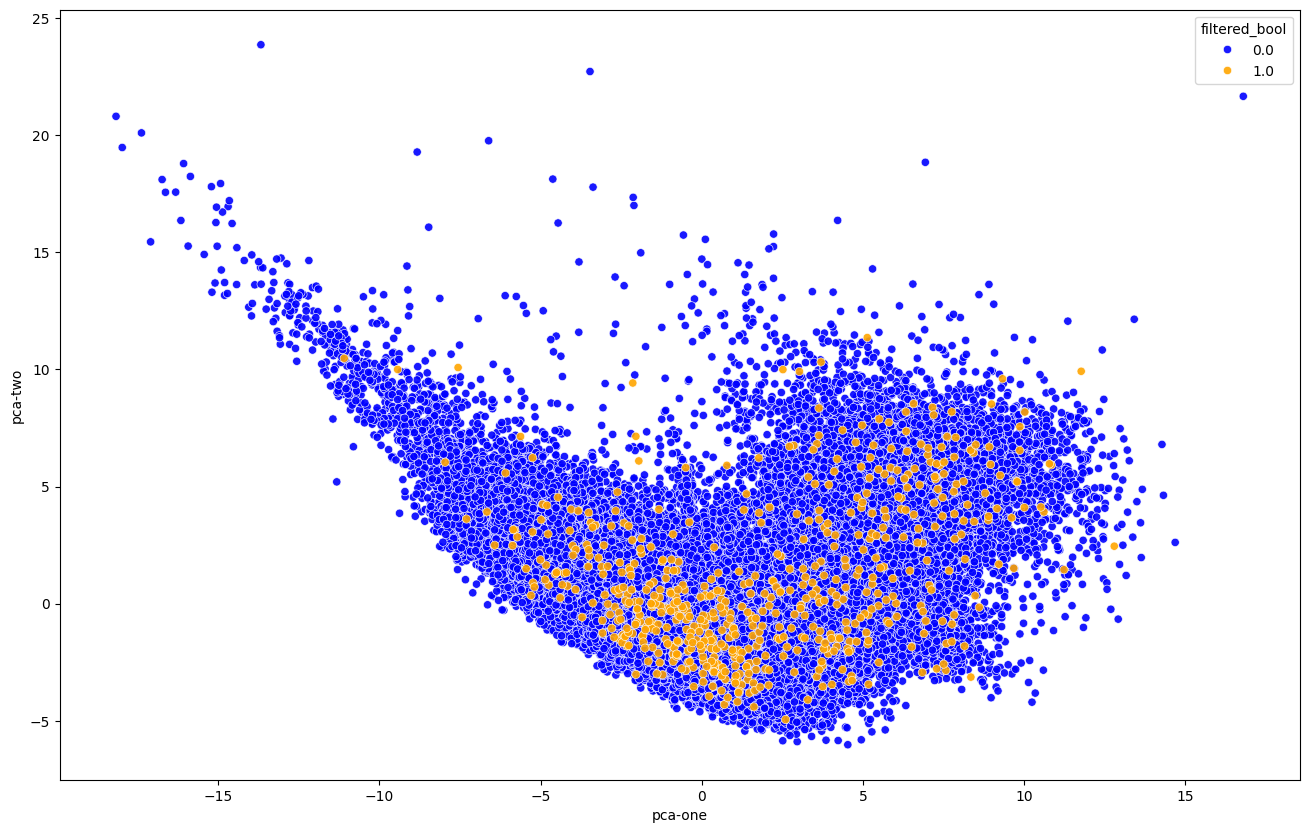

In [107]:
pca.plot_pca(hue='filtered_bool')

# Analysis of multiple nights at once

In [4]:
# load multiple nights, names

from frigate_plots import PrepPlotter
testnights, names = PrepPlotter('./private_data/nights/', cut_drb=0.4, ignore_scores=True, multiple_nights=True).prep_data()

Loaded 96 nights of alerts


### Heatmap

show how many alerts were filtered, were filtered by multiple filters

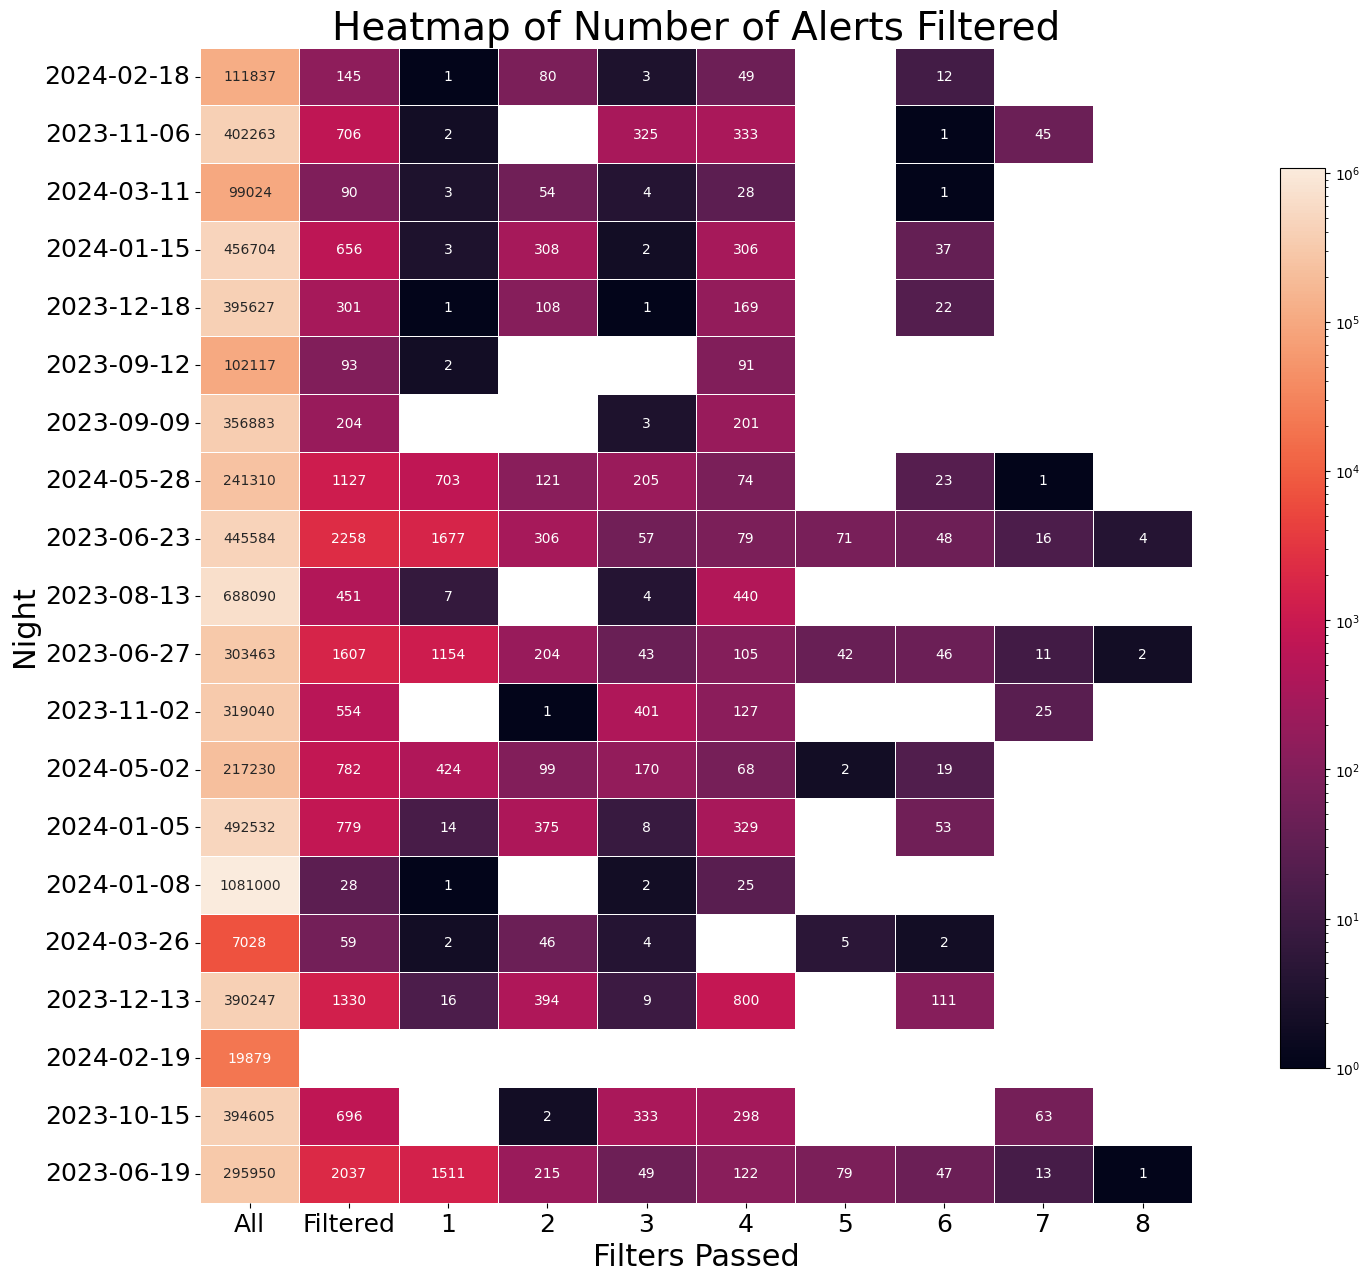

In [81]:
from frigate_plots import HeatmapNumFiltersPassed
heatmap = HeatmapNumFiltersPassed(testnights[-21:-1], names[-21:-1])
heatmap.show_heatmap()

### Parallel Box Plots

show the distribution of a single alert parameter across multiple nights

In [74]:
from frigate_plots import ParallelBoxplots
boxplots = ParallelBoxplots(testnights, names, moon_years=[2023,2024])

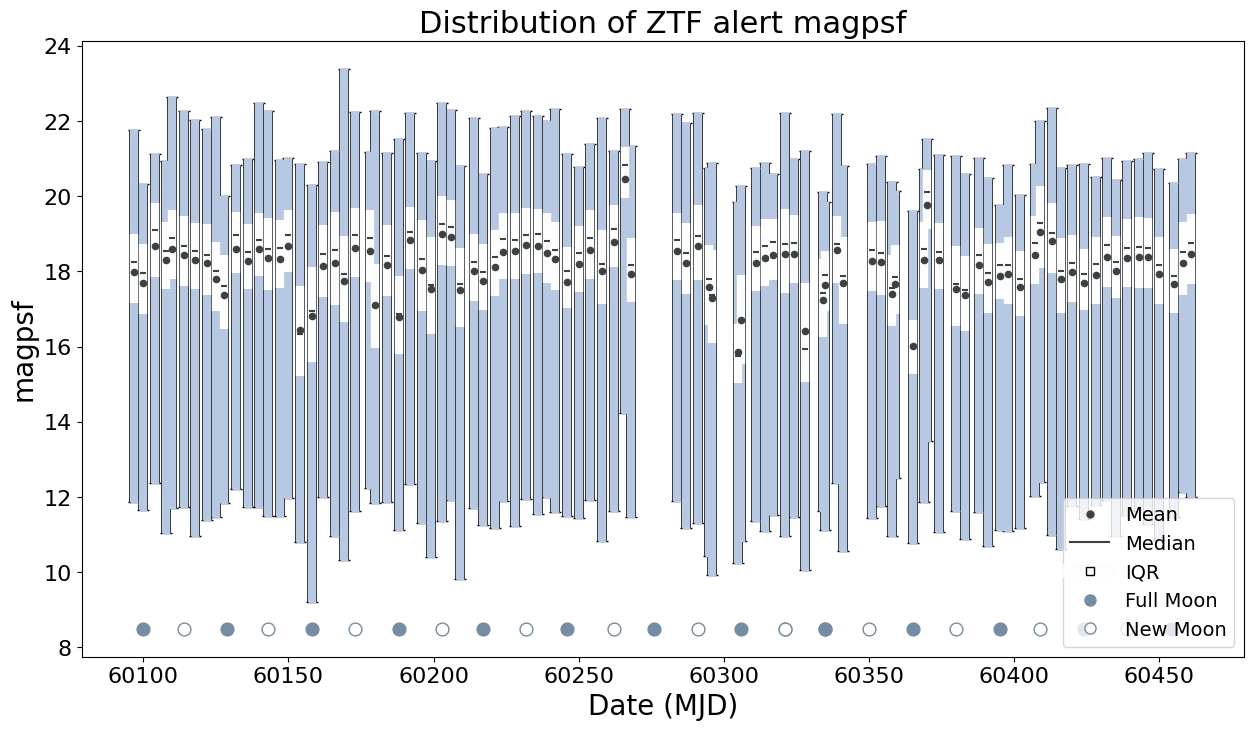

In [75]:
boxplots.show_boxplots('magpsf')

# Filter analysis

### Sankey diagrams

In [89]:
from frigate_plots import Sankey
sankey = Sankey(testnight, name)
sankey.show_sankey()

TypeError: unhashable type: 'numpy.ndarray'

### Chord diagrams

### Hierarchical edge bundling

### Parallel Histogram Plots

In [96]:
import importlib
import frigate_plots
importlib.reload(frigate_plots)

<module 'frigate_plots' from '/home/kira/mypy/repos/frigate/visualizations/frigate_plots.py'>